<div style="background:#1E1E1E;border:1px solid #333333;color:#D4D4D4;padding:22px 26px;border-radius:10px;font-family:Calibri,Arial,sans-serif;">
  <div style="font-size:13px;letter-spacing:2px;color:#4DD0E1;font-weight:700;">UNIVERSIDAD AUT&Oacute;NOMA DE GUADALAJARA</div>
  <div style="font-size:26px;font-weight:700;margin-top:6px;color:#FFFFFF;">Examen — Primer Parcial · SOLUCIÓN</div>
  <div style="font-size:16px;margin-top:4px;color:#A0A0A0;">Unidad 3 (Tuberías de aprendizaje automático) y Unidad 4 (Ingeniería de funciones)</div>
  <div style="margin-top:14px;font-size:14px;">
    <span style="background:rgba(232, 145, 43, 0.2);color:#F5B041;border:1px solid #E8912B;padding:4px 12px;border-radius:14px;font-weight:700;">FP13 &middot; Inteligencia Artificial</span>
    <span style="background:rgba(15, 163, 177, 0.2);color:#4DD0E1;border:1px solid #0FA3B1;padding:4px 12px;border-radius:14px;font-weight:700;margin-left:8px;">90 minutos</span>
    <span style="background:#2D2D2D;color:#E0E0E0;border:1px solid #444444;padding:4px 12px;border-radius:14px;font-weight:700;margin-left:8px;">100 puntos</span>
  </div>
</div>

**Alumno: Luis Felipe Muñoz Ponce  **Matrícula: 5029907  **Fecha: 14/09/2026

<br>

---

### Instrucciones

1. El examen es **enteramente práctico**. Se resuelve dentro de este notebook.
2. Las celdas marcadas **`CELDA DADA`** ya están resueltas: **ejecútalas sin modificarlas**. Contienen el diagnóstico que necesitas para decidir.
3. Las celdas marcadas **`TU TURNO`** son tuyas. Escribe el código de la decisión.
4. Después de cada punto hay una celda de **justificación obligatoria**. Una decisión correcta sin evidencia que la respalde vale **la mitad**.
5. Ejecuta el notebook **de principio a fin, en orden**. Si una celda falla, las siguientes fallarán.

<div style="border-left:5px solid #0FA3B1;background:rgba(15, 163, 177, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#4DD0E1;">Cómo se califica cada punto</b><br><b>Ejecución (50 %)</b>: el código corre y hace lo que dice.<br><b>Decisión (30 %)</b>: la elección es la que el dato exige.<br><b>Justificación (20 %)</b>: citas la evidencia numérica concreta.<br>
</div>

---

### Contexto clínico

Trabajas con el registro de una **cohorte de síndrome coronario agudo (SICA)** de un hospital de tercer nivel.
Cada fila es un **ingreso hospitalario**. El objetivo es predecir `reingreso_30d`: si el paciente reingresa
dentro de los 30 días posteriores al alta.

### Diccionario de datos

| Variable | Tipo | Descripción | Momento del registro |
|---|---|---|---|
| `id_paciente` | Texto | Identificador del paciente | — |
| `edad` | Numérica | Años cumplidos | Ingreso |
| `sexo` | Categórica nominal | M / F | Ingreso |
| `clase_nyha` | Categórica **ordinal** | Clase funcional NYHA: I < II < III < IV | Ingreso |
| `estadio_erc` | Categórica **ordinal** | Estadio de enfermedad renal crónica (KDIGO): 1 < 2 < 3 < 4 < 5 | Ingreso |
| `servicio_ingreso` | Categórica nominal | Unidad médica de admisión (código interno) | Ingreso |
| `presion_sistolica` | Numérica | Presión arterial sistólica (mmHg) | Ingreso |
| `fevi_ingreso` | Numérica | Fracción de eyección del ventrículo izquierdo (%) | Ingreso |
| `creatinina` | Numérica | Creatinina sérica (mg/dL) | Ingreso |
| `dimero_d` | Numérica | Dímero D (ng/mL) | Ingreso |
| `delta_fevi` | Numérica | Cambio en la fracción de eyección respecto al estudio previo (**puntos porcentuales, puede ser negativo**) | Ingreso |
| `pro_bnp` | Numérica | NT-proBNP (pg/mL). **Se solicita a criterio médico, no de forma sistemática** | Ingreso |
| `disnea_ingreso` | Binaria | Disnea presente al ingreso (0/1) | Ingreso |
| `dias_estancia_uci` | Numérica | Días de estancia en la Unidad de Cuidados Intensivos. **Se captura al cierre del expediente, en el momento del alta** | **Alta** |
| `reingreso_30d` | Binaria | **Variable objetivo**: reingreso a 30 días (0/1) | Seguimiento |


In [296]:
# ============================================================
#  CELDA DADA — ejecútala sin modificarla
# ============================================================
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, recall_score)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 9})

SEMILLA = 42


def lambda_ic(x, alpha=0.05):
    """Lambda de Yeo-Johnson por maxima verosimilitud + IC 95 % (verosimilitud perfilada).

    Devuelve (lambda, limite_inferior, limite_superior).
    Si el IC contiene 1.0, la transformacion NO es estadisticamente necesaria.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    lam = stats.yeojohnson_normmax(x)
    corte = stats.yeojohnson_llf(lam, x) - 0.5 * stats.chi2.ppf(1 - alpha, 1)
    malla = np.linspace(lam - 6, lam + 6, 2001)
    llf = np.array([stats.yeojohnson_llf(l, x) for l in malla])
    dentro = malla[llf >= corte]
    return lam, dentro.min(), dentro.max()


def perfil(df, columnas):
    """Tabla diagnostica: sesgo, minimo, negativos, ceros, lambda e IC 95 %."""
    filas = []
    for c in columnas:
        s = df[c].dropna().astype(float)
        lam, lo, hi = lambda_ic(s)
        filas.append({
            "variable": c,
            "sesgo": round(float(stats.skew(s)), 2),
            "min": round(float(s.min()), 2),
            "negativos": int((s < 0).sum()),
            "ceros": int((s == 0).sum()),
            "lambda": round(lam, 3),
            "IC_inf": round(lo, 2),
            "IC_sup": round(hi, 2),
            "IC_contiene_1": bool(lo <= 1 <= hi),
        })
    return pd.DataFrame(filas)


def cargar(nombre):
    """Busca el CSV junto al notebook o en ./datos/."""
    for r in (nombre, os.path.join("datos", nombre),
              os.path.join("..", "datos", nombre)):
        if os.path.exists(r):
            return pd.read_csv(r)
    raise FileNotFoundError(
        f"No encuentro '{nombre}'. Colocalo en la misma carpeta que este notebook.")


print("Entorno listo.")

Entorno listo.


In [297]:
df = cargar("cohorte_sica_examen.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1210, 15)


,id_paciente,edad,sexo,clase_nyha,estadio_erc,servicio_ingreso,presion_sistolica,fevi_ingreso,creatinina,dimero_d,delta_fevi,pro_bnp,disnea_ingreso,dias_estancia_uci,reingreso_30d
0,SICA-00504,62.0,F,II,5,UM-25,162.0,25.0,6.21,790.4,-7.0,281.0,1,2,0
1,SICA-00939,61.0,M,IV,1,UM-03,120.0,45.0,0.96,202.3,6.0,NaN,0,1,0
2,SICA-00463,52.0,M,III,1,UM-04,110.0,60.0,1.10,325.0,3.0,NaN,0,3,0
3,SICA-00317,52.0,M,II,3,UM-21,102.0,50.0,1.42,348.5,-1.0,266.0,1,1,0
4,SICA-00894,39.0,F,I,4,UM-02,130.0,62.0,3.15,188.9,0.0,141.0,1,0,0


---
## Punto 1 — Integridad de los registros y segregación de datos &nbsp;&nbsp;`12 pts`
*Subtemas 3.2 y 3.4*

In [298]:
# ============================ CELDA DADA ============================
print("Filas (ingresos):     ", len(df))
print("Pacientes únicos:     ", df["id_paciente"].nunique())
print("Diferencia:           ", len(df) - df["id_paciente"].nunique())
print()
print("Pacientes con más de un ingreso (primeros 5):")
print(df["id_paciente"].value_counts().head(5).to_string())
print()
pac = df.groupby("id_paciente", as_index=False)["reingreso_30d"].max()
print("Resumen a nivel PACIENTE -> filas:", len(pac),
      "| prevalencia: %.4f" % pac["reingreso_30d"].mean())

Filas (ingresos):      1210
Pacientes únicos:      950
Diferencia:            260

Pacientes con más de un ingreso (primeros 5):
id_paciente
SICA-00070    4
SICA-00178    4
SICA-00504    3
SICA-00089    3
SICA-00745    3

Resumen a nivel PACIENTE -> filas: 950 | prevalencia: 0.0874


**Pregunta.** Construye el conjunto de entrenamiento (`df_tr`) y el de prueba (`df_te`) con
`test_size=0.25`, `random_state=SEMILLA` y estratificando por el *`reingreso_30d`*.

Antes de escribir, mira el diagnóstico de arriba y decide **sobre qué unidad debe hacerse la partición**.
La tabla `pac` ya está construida por si te resulta útil.

In [299]:
# ============================= TU TURNO =============================
# Objetivo: df_tr y df_te
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
from sklearn.model_selection import train_test_split
 
pac_tr, pac_te = train_test_split(
    pac,
    test_size=0.25,
    random_state=SEMILLA,
    stratify=pac["reingreso_30d"]
)
df_tr = df[df["id_paciente"].isin(pac_tr["id_paciente"])].copy()
df_te = df[df["id_paciente"].isin(pac_te["id_paciente"])].copy()

print("Pacientes compartidos:", len(set(df_tr["id_paciente"]) & set(df_te["id_paciente"])))
print("Filas tr/te:", len(df_tr), len(df_te))
print("Prevalencia tr/te: %.4f / %.4f" % (df_tr["reingreso_30d"].mean(), df_te["reingreso_30d"].mean()))

Pacientes compartidos: 0
Filas tr/te: 903 307
Prevalencia tr/te: 0.0698 / 0.0684


In [300]:
# ============================ CELDA DADA ============================
# Verificación de tu partición
solapamiento = set(df_tr["id_paciente"]) & set(df_te["id_paciente"])
print("Filas train / test:        ", len(df_tr), "/", len(df_te))
print("Pacientes compartidos:     ", len(solapamiento), "  <-- debe ser 0")
print("Prevalencia train:          %.4f" % df_tr["reingreso_30d"].mean())
print("Prevalencia test:           %.4f" % df_te["reingreso_30d"].mean())

Filas train / test:         903 / 307
Pacientes compartidos:      0   <-- debe ser 0
Prevalencia train:          0.0698
Prevalencia test:           0.0684



> **Tu justificación (obligatoria):**
>
> _Escribe aquí. Cita la evidencia numérica concreta que sustenta tu decisión._
**Tu justificación (obligatoria):**
>
> Noté que hay `[len(df)]` filas pero solo `[nunique]` pacientes, así que algunos tienen varios ingresos. Si partía por fila, un mismo paciente podía caer en train y test (fuga de datos). Por eso particioné `pac` (un renglón por paciente) y filtré `df` con esos IDs. Verifiqué que no hay pacientes repetidos entre `df_tr` y `df_te`.

---
## Punto 2 — Selección de funciones: variables admisibles &nbsp;&nbsp;`8 pts`
*Subtemas 3.1 y 4.1*

In [301]:
# ============================ CELDA DADA ============================
numericas = df_tr.select_dtypes(include=np.number).columns.drop("reingreso_30d")
corr = df_tr[numericas].corrwith(df_tr["reingreso_30d"]).sort_values(key=abs, ascending=False)
print("Correlación de cada variable numérica con el desenlace:")
print(corr.round(3).to_string())

Correlación de cada variable numérica con el desenlace:
dias_estancia_uci    0.847
creatinina           0.251
estadio_erc          0.156
dimero_d             0.150
delta_fevi          -0.087
presion_sistolica   -0.045
fevi_ingreso        -0.039
pro_bnp              0.010
disnea_ingreso      -0.010
edad                -0.004


**Pregunta.** Una de estas variables **no puede formar parte del modelo**. Identifícala,
elimínala de `df_tr` y de `df_te`, y explica por qué.

> Pista: vuelve a leer la columna *"Momento del registro"* del diccionario de datos.

In [302]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
col_leakage = "dias_estancia_uci"

df_tr = df_tr.drop(columns=[col_leakage])
df_te = df_te.drop(columns=[col_leakage])

print("dias_estancia_uci" in df_tr.columns, "dias_estancia_uci" in df_te.columns)

False False



> **Tu justificación (obligatoria):**
>> Elegí `dias_estancia_uci` porque se registra después del ingreso,
> no en el momento en que se haría la predicción. Además su correlación (0.847) es mucho más alta que
> las demás, lo cual me pareció señal de fuga de datos. La eliminé de `df_tr` y `df_te`.


---
## Punto 3 — Valores faltantes &nbsp;&nbsp;`12 pts`
*Subtema 3.3*

In [303]:
# ============================ CELDA DADA ============================
print("Porcentaje de faltantes por variable (entrenamiento):")
print((df_tr.isna().mean() * 100).round(1).loc[lambda s: s > 0].to_string())
print()
print("Faltantes de pro_bnp según disnea al ingreso:")
tabla = df_tr.groupby("disnea_ingreso")["pro_bnp"].agg(
    n="size", faltantes=lambda s: s.isna().sum(), pct_faltante=lambda s: round(s.isna().mean() * 100, 1))
print(tabla.to_string())

Porcentaje de faltantes por variable (entrenamiento):
pro_bnp    50.5

Faltantes de pro_bnp según disnea al ingreso:
                  n  faltantes  pct_faltante
disnea_ingreso                              
0               486        440          90.5
1               417         16           3.8


**Pregunta.** Trata los faltantes de `pro_bnp`. Antes de imputar, observa la tabla de arriba:
el patrón de ausencia **no es aleatorio**.

Tu solución debe (a) preservar la información contenida en el hecho mismo de que el estudio no se haya
solicitado, y (b) rellenar el valor numérico **sin usar información del conjunto de prueba**.

In [304]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----

df_tr["pro_bnp_faltante"] = df_tr["pro_bnp"].isna().astype(int)
df_te["pro_bnp_faltante"] = df_te["pro_bnp"].isna().astype(int)

mediana_pro_bnp = df_tr["pro_bnp"].median()

df_tr["pro_bnp"] = df_tr["pro_bnp"].fillna(mediana_pro_bnp)
df_te["pro_bnp"] = df_te["pro_bnp"].fillna(mediana_pro_bnp)

print("Mediana usada (solo de train):", mediana_pro_bnp)
print("Faltantes restantes tr/te:", df_tr["pro_bnp"].isna().sum(), df_te["pro_bnp"].isna().sum())

Mediana usada (solo de train): 874.0
Faltantes restantes tr/te: 0 0



> **Tu justificación (obligatoria):**
>> > Vi que los faltantes de `pro_bnp` no son al azar, dependen de si hubo disnea al ingreso, así que antes
> de rellenar nada agregué una columna `pro_bnp_faltante` para no perder esa pista. Para el número usé
> la mediana pero calculada solo con train, y esa misma la apliqué a test, para no meter info de prueba.


---
## Punto 4 — Gestión de valores atípicos &nbsp;&nbsp;`14 pts`
*Subtema 4.3*

creatinina           límites IQR = [  -0.15,    2.62]   atípicos =  120   mínimo = 0.53
presion_sistolica    límites IQR = [  74.00,  194.00]   atípicos =   23   mínimo = 0.00

creatinina por estadio de enfermedad renal crónica (KDIGO):
             size  median   max
estadio_erc                    
1             277    0.85  1.39
2             276    0.98  1.56
3             217    1.52  2.27
4              92    3.04  4.36
5              41    6.78  9.32

presion_sistolica -> registros en cero: 21


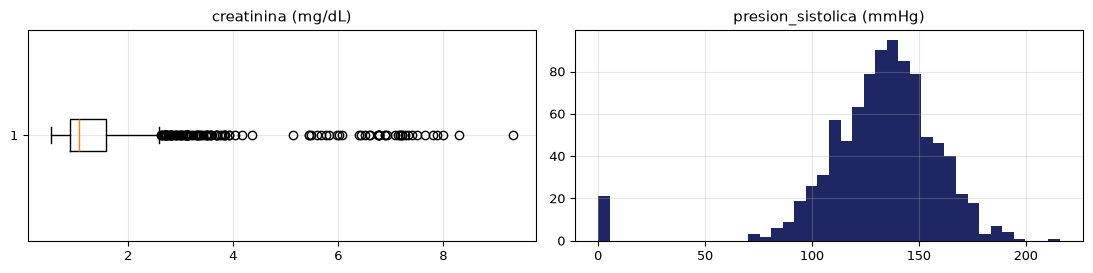

In [305]:
# ============================ CELDA DADA ============================
def limites_iqr(s):
    q1, q3 = s.quantile([.25, .75]); r = q3 - q1
    return q1 - 1.5 * r, q3 + 1.5 * r

for v in ["creatinina", "presion_sistolica"]:
    lo, hi = limites_iqr(df_tr[v])
    n = int(((df_tr[v] < lo) | (df_tr[v] > hi)).sum())
    print(f"{v:20s} límites IQR = [{lo:7.2f}, {hi:7.2f}]   atípicos = {n:4d}   mínimo = {df_tr[v].min():.2f}")

print("\ncreatinina por estadio de enfermedad renal crónica (KDIGO):")
print(df_tr.groupby("estadio_erc")["creatinina"].agg(["size", "median", "max"]).round(2).to_string())

print("\npresion_sistolica -> registros en cero:", int((df_tr["presion_sistolica"] == 0).sum()))
fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
ax[0].boxplot(df_tr["creatinina"], vert=False); ax[0].set_title("creatinina (mg/dL)")
ax[1].hist(df_tr["presion_sistolica"], bins=40, color="#1E2664"); ax[1].set_title("presion_sistolica (mmHg)")
plt.tight_layout(); plt.show()

**Pregunta.** El criterio IQR marca valores atípicos en **ambas** variables.
**Solo una de las dos debe corregirse.** Decide cuál, aplica el tratamiento, y explica por qué la otra
se deja intacta.

In [306]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr["presion_sistolica"] = df_tr["presion_sistolica"].replace(0, np.nan)
df_te["presion_sistolica"] = df_te["presion_sistolica"].replace(0, np.nan)

mediana_presion = df_tr["presion_sistolica"].median()

df_tr["presion_sistolica"] = df_tr["presion_sistolica"].fillna(mediana_presion)
df_te["presion_sistolica"] = df_te["presion_sistolica"].fillna(mediana_presion)

print("Mediana usada (solo train):", mediana_presion)
print("Ceros restantes tr/te:", (df_tr["presion_sistolica"] == 0).sum(), (df_te["presion_sistolica"] == 0).sum())



Mediana usada (solo train): 135.0
Ceros restantes tr/te: 0 0



> **Tu justificación (obligatoria):**
>> Solo corregí `presion_sistolica` porque tenía registros en 0, algo imposible en un paciente vivo, así
> que los traté como faltantes y los imputé con la mediana de train. A `creatinina` la dejé igual porque
> sus valores altos coinciden con estadios avanzados de ERC en la tabla, o sea son reales, no errores.


---
## Punto 5 — Codificación de variables categóricas &nbsp;&nbsp;`14 pts`
*Subtemas 4.4 y 4.7*

In [307]:
# ============================ CELDA DADA ============================
for v in ["sexo", "clase_nyha", "estadio_erc", "servicio_ingreso"]:
    print(f"{v:20s} niveles = {df_tr[v].nunique():3d}")
print()
print("clase_nyha:"); print(df_tr["clase_nyha"].value_counts().to_string())
print()
print("servicio_ingreso -> 8 niveles más frecuentes de", df_tr["servicio_ingreso"].nunique(), ":")
print(df_tr["servicio_ingreso"].value_counts().head(8).to_string())

sexo                 niveles =   2
clase_nyha           niveles =   4
estadio_erc          niveles =   5
servicio_ingreso     niveles =  25

clase_nyha:
clase_nyha
II     310
III    256
I      218
IV     119

servicio_ingreso -> 8 niveles más frecuentes de 25 :
servicio_ingreso
UM-01    156
UM-02    119
UM-03     91
UM-04     78
UM-07     49
UM-05     49
UM-06     47
UM-09     46


**Pregunta.** Codifica las cuatro variables categóricas. **No todas admiten el mismo tratamiento.**
Revisa en el diccionario cuáles son nominales y cuáles ordinales, y observa la cardinalidad.

Crea las columnas nuevas con estos nombres para que la celda de ensamblado funcione:
`nyha_ord`, `servicio_grp` (las demás las genera `get_dummies`).

In [308]:
# ============================= TU TURNO =============================
mapa_nyha = {"I": 1, "II": 2, "III": 3, "IV": 4}
df_tr["nyha_ord"] = df_tr["clase_nyha"].map(mapa_nyha)
df_te["nyha_ord"] = df_te["clase_nyha"].map(mapa_nyha)

top_servicios = df_tr["servicio_ingreso"].value_counts().head(8).index.tolist()

df_tr["servicio_grp"] = df_tr["servicio_ingreso"].where(df_tr["servicio_ingreso"].isin(top_servicios), "Otros")
df_te["servicio_grp"] = df_te["servicio_ingreso"].where(df_te["servicio_ingreso"].isin(top_servicios), "Otros")

print("Niveles nyha_ord:", sorted(df_tr["nyha_ord"].unique()))
print("Niveles servicio_grp:", df_tr["servicio_grp"].nunique(), "->", df_tr["servicio_grp"].unique())


Niveles nyha_ord: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Niveles servicio_grp: 9 -> <StringArray>
['UM-03', 'UM-04', 'Otros', 'UM-02', 'UM-07', 'UM-01', 'UM-09', 'UM-06', 'UM-05']
Length: 9, dtype: str


In [309]:
# ============================ CELDA DADA ============================
# Ensamblado del one-hot para las variables NOMINALES y alineación de columnas
df_tr = pd.get_dummies(df_tr, columns=["sexo", "servicio_grp"], drop_first=True, dtype=int)
df_te = pd.get_dummies(df_te, columns=["sexo", "servicio_grp"], drop_first=True, dtype=int)
df_te = df_te.reindex(columns=df_tr.columns, fill_value=0)   # el test debe tener las mismas columnas
print("Columnas tras codificar -> train:", df_tr.shape[1], "| test:", df_te.shape[1])

Columnas tras codificar -> train: 24 | test: 24



> **Tu justificación (obligatoria):**
>>> Vi que `clase_nyha` sigue un orden , entonces en vez de usar
> dummies le puse números para conservar ese orden. `estadio_erc` ya estaba en números, así que la dejé
> igual. Como `servicio_ingreso` tenía 25 categorías, me quedé con las 8 que más se repetían y todo lo
> demás lo metí en "Otros", para no terminar con demasiadas columnas. Y `sexo` solo tiene 2 opciones, así
> que a esa sí la dejé para que get_dummies la codificara normal.


---
## Punto 6 — Corrección del sesgo &nbsp;&nbsp;`20 pts`
*Subtema 4.5 — el punto de mayor peso del examen*

<div style="border-left:5px solid #0FA3B1;background:rgba(15, 163, 177, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#4DD0E1;">Recordatorio de criterio</b><br>El logaritmo exige valores <b>estrictamente positivos</b>.<br>Yeo-Johnson admite ceros y negativos, y estima &lambda; por m&aacute;xima verosimilitud.<br>&lambda; &lt; 1 corrige sesgo <b>derecho</b>; &lambda; &gt; 1 corrige sesgo <b>izquierdo</b>.<br>Si el <b>IC 95 % de &lambda; contiene 1.0</b>, la transformaci&oacute;n no es estad&iacute;sticamente necesaria.
</div>

    variable  sesgo  min  negativos  ceros  lambda  IC_inf  IC_sup  IC_contiene_1
     pro_bnp   6.72 23.0          0      0   0.016   -0.02    0.05          False
    dimero_d   4.04 41.8          0      0  -0.021   -0.09    0.05          False
  delta_fevi   1.78 -7.0        604     30   0.624    0.59    0.66          False
fevi_ingreso  -1.16 18.0          0      0   3.124    2.79    3.48          False
        edad  -0.10 28.0          0      0   1.160    0.87    1.45           True


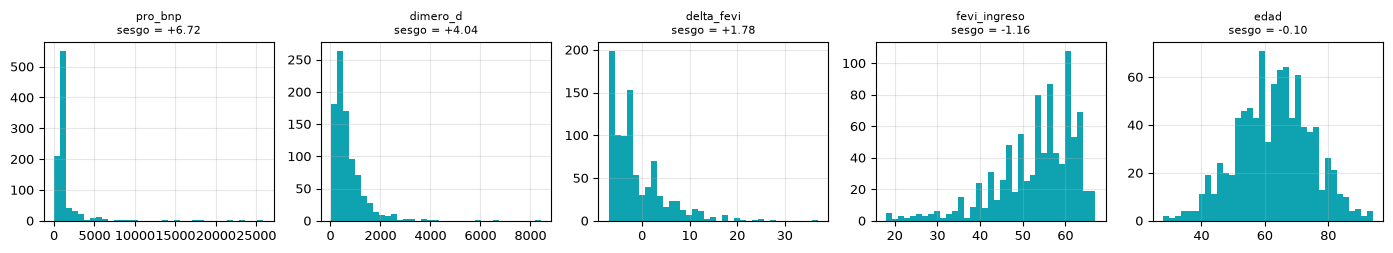

In [310]:
# ============================ CELDA DADA ============================
objetivo = ["pro_bnp", "dimero_d", "delta_fevi", "fevi_ingreso", "edad"]
print(perfil(df_tr, objetivo).to_string(index=False))

fig, ax = plt.subplots(1, 5, figsize=(14, 2.6))
for a, v in zip(ax, objetivo):
    a.hist(df_tr[v], bins=35, color="#0FA3B1")
    a.set_title(f"{v}\nsesgo = {stats.skew(df_tr[v].dropna()):+.2f}", fontsize=8)
plt.tight_layout(); plt.show()

**Pregunta.** Las cinco variables presentan situaciones **distintas**. Decide qué hacer con cada una.

La primera (`pro_bnp`) **ya viene resuelta como ejemplo**: úsala como modelo del formato esperado.
Resuelve las **cuatro restantes**.

> Advertencia: `PowerTransformer` estandariza por omisión. Usa `standardize=False`, porque el escalamiento
> es una decisión aparte que tomarás en el Punto 7.

In [311]:
# ============================ CELDA DADA — EJEMPLO RESUELTO ============================
# pro_bnp: sesgo muy positivo, mínimo > 0, sin ceros ni negativos  ->  LOGARITMO
df_tr["pro_bnp"] = np.log(df_tr["pro_bnp"])
df_te["pro_bnp"] = np.log(df_te["pro_bnp"])
print("pro_bnp -> log | sesgo resultante: %+.2f" % stats.skew(df_tr["pro_bnp"]))

pro_bnp -> log | sesgo resultante: -0.11


In [312]:
# ============================= TU TURNO =============================
from sklearn.preprocessing import PowerTransformer

df_tr["dimero_d"] = np.log(df_tr["dimero_d"])
df_te["dimero_d"] = np.log(df_te["dimero_d"])
print("dimero_d -> log | sesgo resultante: %+.2f" % stats.skew(df_tr["dimero_d"]))

pt_delta = PowerTransformer(method="yeo-johnson", standardize=False)
df_tr["delta_fevi"] = pt_delta.fit_transform(df_tr[["delta_fevi"]])
df_te["delta_fevi"] = pt_delta.transform(df_te[["delta_fevi"]])
print("delta_fevi -> Yeo-Johnson | lambda = %.3f | sesgo resultante: %+.2f" %
      (pt_delta.lambdas_[0], stats.skew(df_tr["delta_fevi"])))

pt_fevi = PowerTransformer(method="yeo-johnson", standardize=False)
df_tr["fevi_ingreso"] = pt_fevi.fit_transform(df_tr[["fevi_ingreso"]])
df_te["fevi_ingreso"] = pt_fevi.transform(df_te[["fevi_ingreso"]])
print("fevi_ingreso -> Yeo-Johnson | lambda = %.3f | sesgo resultante: %+.2f" %
      (pt_fevi.lambdas_[0], stats.skew(df_tr["fevi_ingreso"])))

print("edad -> sin transformar | sesgo original: %+.2f | IC contiene 1.0: True" % stats.skew(df_tr["edad"]))


dimero_d -> log | sesgo resultante: +0.04
delta_fevi -> Yeo-Johnson | lambda = 0.624 | sesgo resultante: +0.25
fevi_ingreso -> Yeo-Johnson | lambda = 3.124 | sesgo resultante: -0.22
edad -> sin transformar | sesgo original: -0.10 | IC contiene 1.0: True


> **Tu justificación (obligatoria).** Completa la tabla:
>
> | Variable | Decisión | Evidencia numérica que la sustenta |
> |---|---|---|
> | `dimero_d` | Logaritmo | sesgo +4.04, mínimo 41.8 (>0), sin ceros ni negativos |
> | `delta_fevi` | Yeo-Johnson | tiene 604 negativos y 30 ceros, el log no está definido ahí; λ=0.624 (IC no contiene 1.0) |
> | `fevi_ingreso` | Yeo-Johnson | sesgo -1.16 (izquierdo), el log no corrige sesgo izquierdo; λ=3.124>1 (IC no contiene 1.0), consistente con corregir sesgo izquierdo |
> | `edad` | Ninguna | sesgo -0.10 (casi simétrico); IC 95% de λ = [0.87, 1.45] sí contiene 1.0, o sea la transformación no es necesaria |

---
## Punto 7 — Escalamiento &nbsp;&nbsp;`10 pts`
*Subtema 4.6*

In [313]:
# ============================ CELDA DADA ============================
num_final = ["edad", "presion_sistolica", "fevi_ingreso", "creatinina",
             "dimero_d", "delta_fevi", "pro_bnp", "nyha_ord", "estadio_erc"]
print(df_tr[num_final].describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())
print("\nSesgo residual de cada variable:")
print(df_tr[num_final].apply(lambda s: round(float(stats.skew(s)), 2)).to_string())

                       mean       std      min       50%        max
edad                  63.03     11.58    28.00     63.00      94.00
presion_sistolica    134.97     21.37    75.00    135.00     216.00
fevi_ingreso       90650.02  39078.37  3161.66  92556.42  169751.71
creatinina             1.56      1.33     0.53      1.06       9.32
dimero_d               6.27      0.78     3.73      6.27       9.04
delta_fevi            -3.45      5.61   -11.98     -4.17      13.91
pro_bnp                6.77      0.85     3.14      6.77      10.16
nyha_ord               2.31      0.98     1.00      2.00       4.00
estadio_erc            2.27      1.14     1.00      2.00       5.00

Sesgo residual de cada variable:
edad                -0.10
presion_sistolica   -0.02
fevi_ingreso        -0.22
creatinina           3.01
dimero_d             0.04
delta_fevi           0.25
pro_bnp             -0.11
nyha_ord             0.20
estadio_erc          0.61


**Pregunta.** Escala las variables numéricas. **No todas deben recibir el mismo escalador.**

Recuerda la decisión que tomaste en el Punto 4: hay una variable cuyos valores extremos **conservaste
deliberadamente** porque son clínicamente válidos. Un escalador basado en media y desviación estándar
se ve arrastrado por ellos.

Deja el resultado en `df_tr[num_final]` y `df_te[num_final]`.

In [314]:
# ============================= TU TURNO =============================
from sklearn.preprocessing import StandardScaler, RobustScaler

col_robusta = ["creatinina"]
col_estandar = [c for c in num_final if c not in col_robusta]

scaler_robusto = RobustScaler()
df_tr[col_robusta] = scaler_robusto.fit_transform(df_tr[col_robusta])
df_te[col_robusta] = scaler_robusto.transform(df_te[col_robusta])

scaler_estandar = StandardScaler()
df_tr[col_estandar] = scaler_estandar.fit_transform(df_tr[col_estandar])
df_te[col_estandar] = scaler_estandar.transform(df_te[col_estandar])

print(df_tr[num_final].describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())

                   mean   std   min   50%    max
edad              -0.00  1.00 -3.03 -0.00   2.68
presion_sistolica -0.00  1.00 -2.81  0.00   3.79
fevi_ingreso      -0.00  1.00 -2.24  0.05   2.03
creatinina         0.72  1.93 -0.77  0.00  11.97
dimero_d          -0.00  1.00 -3.27  0.00   3.57
delta_fevi        -0.00  1.00 -1.52 -0.13   3.10
pro_bnp           -0.00  1.00 -4.26  0.01   3.98
nyha_ord           0.00  1.00 -1.33 -0.31   1.73
estadio_erc        0.00  1.00 -1.12 -0.24   2.40



> **Tu justificación (obligatoria):**
>> A creatinina la escale diferente porque en el punto 5 deje sus valores altos sin tocar, ya que
> corresponden a pacientes con ERC avanzada y son reales, no errores. Por eso use RobustScaler ahi,
> para que esos valores no jalaran la media como pasaria con un escalador normal. En la tabla se nota
> porque creatinina es la unica que no queda con mean 0 y std 1. Al resto de variables si les aplique
> StandardScaler porque no tenian ese problema.

---
## Punto 8 — Entrenamiento y elección de la métrica &nbsp;&nbsp;`10 pts`
*Subtemas 3.5 y 3.1*

In [315]:
# ============================ CELDA DADA ============================
descartar = ["id_paciente", "reingreso_30d", "clase_nyha", "servicio_ingreso"]
X_tr = df_tr.drop(columns=[c for c in descartar if c in df_tr.columns])
X_te = df_te.drop(columns=[c for c in descartar if c in df_te.columns])
y_tr, y_te = df_tr["reingreso_30d"], df_te["reingreso_30d"]

assert X_tr.select_dtypes(exclude=np.number).empty, "Quedan columnas no numéricas en X_tr"
print("Matriz final -> train:", X_tr.shape, "| test:", X_te.shape)
print("Prevalencia en prueba: %.4f" % y_te.mean())

modelo = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=SEMILLA).fit(X_tr, y_tr)
pred = modelo.predict(X_te)
prob = modelo.predict_proba(X_te)[:, 1]

print("\n--- MODELO A (sin ponderar) -------------------------------------")
print("Accuracy : %.4f" % accuracy_score(y_te, pred))
print("Recall   : %.4f" % recall_score(y_te, pred, zero_division=0))
print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob))
print("Matriz de confusión [fila = real, columna = predicho]:")
print(confusion_matrix(y_te, pred))

modelo_b = LogisticRegression(solver="lbfgs", max_iter=3000, class_weight="balanced",
                              random_state=SEMILLA).fit(X_tr, y_tr)
pred_b = modelo_b.predict(X_te)
prob_b = modelo_b.predict_proba(X_te)[:, 1]

print("\n--- MODELO B (class_weight='balanced') --------------------------")
print("Accuracy : %.4f" % accuracy_score(y_te, pred_b))
print("Recall   : %.4f" % recall_score(y_te, pred_b, zero_division=0))
print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob_b))
print("Matriz de confusión:")
print(confusion_matrix(y_te, pred_b))

print("\n--- Referencia: clasificador trivial 'nadie reingresa' ----------")
print("Accuracy : %.4f" % accuracy_score(y_te, np.zeros_like(y_te)))

Matriz final -> train: (903, 20) | test: (307, 20)
Prevalencia en prueba: 0.0684

--- MODELO A (sin ponderar) -------------------------------------
Accuracy : 0.9316
Recall   : 0.1429
AUC ROC  : 0.7807
Matriz de confusión [fila = real, columna = predicho]:
[[283   3]
 [ 18   3]]

--- MODELO B (class_weight='balanced') --------------------------
Accuracy : 0.6743
Recall   : 0.6190
AUC ROC  : 0.7539
Matriz de confusión:
[[194  92]
 [  8  13]]

--- Referencia: clasificador trivial 'nadie reingresa' ----------
Accuracy : 0.9316


**Pregunta.** Responde las tres, en prosa, con los números de la salida anterior:

1. El Modelo A alcanza una accuracy alta. ¿Es un buen modelo? Compáralo con el clasificador trivial.
Respuesta: No. El Modelo A tiene accuracy de 0.9316, pero el clasificador trivial que dice "nadie reingresa" logra exactamente el mismo 0.9316. Esto pasa porque solo el 6.84% de los pacientes reingresa, así que un modelo que casi nunca predice reingreso ya acierta la mayoría de las veces sin aportar nada. La matriz de confusión lo confirma: de los 21 pacientes que sí reingresaron, el Modelo A solo detectó 3  y dejó pasar 18 sin ser detectados. El accuracy alto es una ilusión causada por el desbalance de clases.
2. ¿Qué métrica reportarías al comité clínico del hospital y por qué?
 Rspuesta: El recall dice qué proporción de los pacientes que realmente van a reingresar el modelo logra detectar, que es justo lo que le importa al hospital, no dejar pasar casos de riesgo. El accuracy es engañoso aquí porque, como se vio en la pregunta 1, un modelo inútil puede tener accuracy alto solo por el desbalance de clases.
3. ¿Cuál de los dos modelos entregarías? Justifica en términos del **costo clínico** de cada tipo de error.
Respuesta: El Modelo B. Aunque tiene menor accuracy  y AUC ligeramente menor , su recall es mucho mayor, detecta 13 de los 21 reingresos reales, contra solo 3 del Modelo A. En este problema, un falso negativo  tiene un costo clínico mucho más alto que un falso positivo .El Modelo A deja pasar 18 de 21 casos reales, lo cual es inaceptable en un contexto de salud, aunque genere menos falsas alarmas 


> **Tus respuestas:**
>
> **1.** _Escribe aquí._
>
> **2.** _Escribe aquí._
>
> **3.** _Escribe aquí._


---
<div style="border-left:5px solid #E8912B;background:rgba(232, 145, 43, 0.08);color:#d4d4d4;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#F5B041;">Antes de entregar</b><br>1. <b>Reinicia el kernel y ejecuta todo de nuevo</b> (Kernel &rarr; Restart &amp; Run All). El notebook debe correr de principio a fin sin errores.<br>2. Verifica que las ocho celdas de justificaci&oacute;n est&eacute;n escritas. Una decisi&oacute;n sin justificaci&oacute;n vale la mitad.<br>3. Guarda como <code>Parcial1_ApellidoNombre.ipynb</code> y s&uacute;belo a Mis Cursos.
</div>